# Ders 3 — Görüntü Verisi ve Ön İşleme: Piksellerden Tensörlere

**Program:** Python ile Derin Öğrenme Tabanlı Görüntü ve Doğal Dil İşleme
**Modül 2 · Oturum 3** · Önerilen süre: 4 saat

## Bu oturumun hedefleri
1. Bir görüntünün bellekte nasıl durduğunu (piksel matrisi, kanal sırası, değer aralığı) açıklayabilmek
2. Görüntüyü PyTorch'un beklediği biçime getirebilmek: normalize, `permute` ile CHW düzeni, batch boyutu
3. RGB ile HSV renk uzaylarını ayırt edip renk tabanlı maske çıkarabilmek
4. Konvolüsyon işlemini 3×3 kernel örneğiyle **elle** hesaplayabilmek
5. OpenCV ile bulanıklaştırma ve Sobel kenar algılama uygulayabilmek

> **Nasıl çalışılır:** Hücreleri yukarıdan aşağıya `Shift+Enter` ile çalıştır.
> Sarı kutular animasyonlu anlatım videolarıdır (HyperFrames ile üretildi).

## 1 · Görüntü Bir Piksel Matrisidir

Derin öğrenmenin gözünde bir fotoğraf **sayı tablosundan** ibarettir. Gri tonlu bir görüntü, her hücresi bir pikselin parlaklığını tutan matristir; renkli görüntüde her piksel üç sayı taşır: kırmızı, yeşil ve mavi (RGB) şiddetleri.

| Veri | `shape` | Gerçek dünya karşılığı |
|---|---|---|
| Gri görüntü | `[H, W]` | 240×320 piksel, tek kanal |
| Renkli görüntü | `[H, W, 3]` | 240×320, RGB kanalları |
| Mini-batch | `[B, H, W, 3]` | 32 görüntü tek yığında |

Modele girmeden önce iki ayrıntı düzeltilir:

1. **Değer aralığı:** Pikseller `uint8` tipinde 0–255 arasıdır. Ağlar float sayılarla ve benzer ölçeklerle çalışmayı sever; büyük sayılar eğitimi kararsızlaştırır. Çözüm: **normalize** — 255'e böleriz, aralık 0–1 olur.
2. **Boyut sırası:** Dosya biçimleri ve `numpy` "[yükseklik, genişlik, kanal]" (HWC) düzenini kullanır; PyTorch konvolüsyon katmanları "[kanal, yükseklik, genişlik]" (CHW) ister. Bu çeviriyi 5. bölümde tek tek kuracağız.

### Arka plandaki matematik

Bilgisayarın gözünde bir fotoğraf **sayı tablosundan** ibarettir: gri tonlu görüntü $[H, W]$ boyutunda, renkli görüntü ise $[H, W, 3]$ boyutunda bir matristir — her hücre o pikselin parlaklığını tutar, $0$ koyu, $255$ açık. **Tensör** (çok boyutlu sayı tablosu) bu matrislerin derin öğrenmedeki genel adıdır. Modeller ondalıklı ve benzer ölçekli sayılarla çalışmayı sevdiği için her piksel önce ölçeklenir:

$$x' = \frac{x - 0}{255}$$

Elle örnek: $x = 89 \Rightarrow x' = 89/255 \approx 0{,}35$; $x = 255 \Rightarrow 1{,}0$; $x = 0 \Rightarrow 0{,}0$. Böylece tüm değerler $[0, 1]$ aralığına iner.

> Bu blok piksel tensörü için gerekli: klip bir görüntünün matristen normalleştirilmiş tensöre dönüşümünü izletiyor; bu formülü baştan kurmak, "görüntü = sayı tablosu" fikrinin kodda nasıl somutlaştığını görmemizi sağlar.


In [1]:
# IPython'un Video sınıfını getirir: ders kliplerini notebook hücresi içinde oynatmak için.
from IPython.display import Video

# 1.1 — Piksel matrisinden tensora yolculuk
# Klipi assets/ klasöründen bulur, genişliğini 1000 piksele ayarlar;
# embed=True videoyu notebook dosyasının içine gömer: dosya yeri değişse bile kaybolmaz.
Video("assets/01-piksel-tensor-yolculugu.mp4", width=1000, embed=True)

### Sentetik bir görüntüyü piksel piksel okumak

Kamera ya da dosya kullanmadan, küçük bir 8×8'lik görüntüyü `numpy` dizisi olarak üretiyoruz: renk, her pikselin satır + sütun konumuna göre değişiyor. Bilgisayarın "gördüğü", sağdaki tabloda gördüğünüz sayılardır — görüntü diye bir şey yok, sadece sayılar var.

### Arka plandaki matematik

Görüntü zaten bir matristir; bu hücre her pikselin rengini konumunun doğrusal fonksiyonu olarak yazar, örneğin $R(i,j) = 23 + 228\,t(i,j)$ — burada $t \in [0, 1]$ konumun normalleştirilmiş hâlidir.

> Bu blok için gerekli: görüntüyü elle üretip her karenin değerini yazdırmak, "piksel = matris elemanı" özdeşliğini gözle kanıtlar; sonraki tüm dönüşümlerin uygulanacağı nesneyi tanırız.


dtype: uint8 | shape: (8, 8, 3)
değer aralığı: 23 - 251

sol üst piksel (0,0): [23 88 82] -> koyu deniz mavisi
sağ alt piksel (7,7): [251 191  36] -> amber


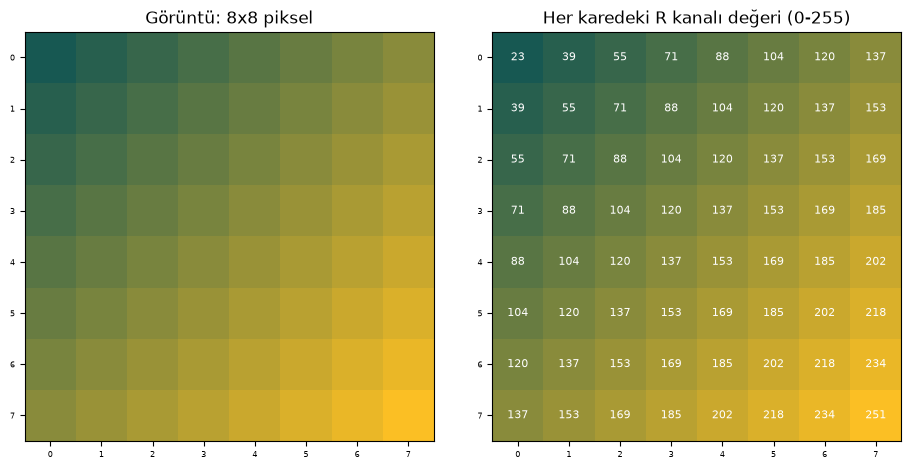

In [2]:
# numpy sayı tablolarını (dizi üretimi, mgrid, min/max), matplotlib çizimi yönetir;
# görüntüyü üretip ekrana basmak için ikisi de şart.
import numpy as np
import matplotlib.pyplot as plt

# 8x8'lik sentetik görüntü: renk, satır + sütun konumuna göre değişiyor
# Görüntüyü küçük tutuyoruz: 64 pikselin her biri gözle takip edilebilsin.
H, W = 8, 8
# Her hücreye kendi satır (yy) ve sütun (xx) numarasını yazan iki tablo üretir;
# rengi konuma bağlayacak t değerini hesaplamak için gerekli.
yy, xx = np.mgrid[0:H, 0:W]
# Konumu 0-1 aralığına taşır: sol üstte t=0, sağ altta t=1;
# bölen, kat edilebilecek en uzun yol olan satır+sütun toplamıdır.
t = (yy + xx) / (H + W - 2)                       # 0.0 (koyu) - 1.0 (açık)

# Boş renkli tuval: 8 satır x 8 sütun x 3 kanal;
# uint8 (0-255 tam sayı) görüntülerin standart depolama tipidir.
img_255 = np.zeros((H, W, 3), dtype=np.uint8)
# Koyu köşede az, açık köşede çok kırmızı: koyu deniz mavisi -> amber geçişini üretir.
img_255[..., 0] = 23 + 228 * t                    # R kanalı: 23 -> 251
# Yeşil bileşen de açıldıkça artar; geçişin canlılığını korur.
img_255[..., 1] = 88 + 103 * t                    # G kanalı: 88 -> 191
# Mavi ters yönde azalır: sağ alt köşe maviyi bırakıp amber'e döner.
img_255[..., 2] = 82 - 46 * t                     # B kanalı: 82 -> 36

# Tipi, şekli ve değer aralığını yazdırır: "görüntü bir sayı tablosudur" iddiasının kanıtı.
print("dtype:", img_255.dtype, "| shape:", img_255.shape)
# Minimum ve maksimumu basarak uint8 aralığının uçlarını (0 ve 255) gösterir.
print("değer aralığı:", img_255.min(), "-", img_255.max())
print()
# (0,0) köşe pikselinin üç kanalını basar: koyu uç.
print("sol üst piksel (0,0):", img_255[0, 0], "-> koyu deniz mavisi")
# (7,7) köşe pikselinin üç kanalını basar: açık uç.
print("sağ alt piksel (7,7):", img_255[7, 7], "-> amber")

# Yan yana iki boş panel açar: solda görüntü, sağda değer tablosu.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
# Diziyi piksel piksel ekrana basar; nearest komşu pikselleri yumuşatmaz, kareler net kalır.
axes[0].imshow(img_255, interpolation="nearest")
# Sol panelin başlığı.
axes[0].set_title("Görüntü: 8x8 piksel")
# Sağ panel için aynı görüntüyü yeniden basar; üzerine değerler yazılacak.
axes[1].imshow(img_255, interpolation="nearest")
# 64 pikselin her birine tek tek uğrar: değer tablosunu yazdırmak için gerekli.
for i in range(H):
    # Her satırda sütun sütun ilerler.
    for j in range(W):
        # (i, j) karesinin üzerine o pikselin R kanalı değerini yazar;
        # görüntü ile tablonun aynı şey olduğu ekranda görünür.
        axes[1].text(j, i, int(img_255[i, j, 0]), ha="center", va="center",
                     fontsize=8, color="white")
# Sağ panelin başlığı: tablonun ne gösterdiğini söyler.
axes[1].set_title("Her karedeki R kanalı değeri (0-255)")
# Eksenleri 0-7 piksel koordinatlarına ayarlar: tablo okumasını kolaylaştırır.
for ax in axes:
    ax.set_xticks(range(W)); ax.set_yticks(range(H))
    # Rakamları küçültür: 8 sütunluk tabloda okunabilir kalır.
    ax.tick_params(labelsize=6)
# tight_layout panelleri birbirine sokar; show figürü ekrana basar.
plt.tight_layout(); plt.show()

### 0–255'ten 0–1'e ve tek görüntüden mini-batch'a

**Normalize** etmek için diziye 255'e bölme uygularız; `uint8` (tam sayı) yerine `float32` (ondalıklı) gelir. Eğitimde görüntüler tek tek değil, **mini-batch** adı verilen küçük yığınlar hâlinde işlenir; 4 görüntülük bir batch'in şekli `[4, H, W, 3]`'tür — ilk boyut "kaç örnek" sorusuna cevap verir.

### Arka plandaki matematik

Ölçekleme yine aynı formül, $x' = x/255$ (örnek: $x = 204 \Rightarrow 0{,}80$); mini-batch adımı ise tek görüntüyü $B$ kez üst üste yığarak şekli $[H, W, 3]$'ten $[B, H, W, 3]$'e büyütür — matematiği ekstra bir dış boyut atmaktan ibarettir.

> Bu blok için gerekli: normalize ve batch etiketli bu iki adım, modelin beklediği veri düzeninin ilk halkasıdır; torch'a geçmeden önce şekil değişimini numpy'da elle görmek dönüşümleri kalıcılaştırır.


In [3]:
# numpy dizileri ve tipleri: normalize ve batch işlemleri numpy üzerinde yapılır.
import numpy as np

# Hücreyi tek başına çalıştırmak için görüntüyü yeniden üretiyoruz
H, W = 8, 8
# satır/sütun numara tabloları (bölüm 1'deki kalıbın aynısı).
yy, xx = np.mgrid[0:H, 0:W]
# konumun 0-1 aralığına normalize hâli.
t = (yy + xx) / (H + W - 2)
img_255 = np.zeros((H, W, 3), dtype=np.uint8)
# R kanalı: 23 -> 251 (koyudan açığa).
img_255[..., 0] = 23 + 228 * t
# G kanalı: 88 -> 191.
img_255[..., 1] = 88 + 103 * t
# B kanalı: 82 -> 36 (ters yönde).
img_255[..., 2] = 82 - 46 * t

# 1) normalize: uint8 (0-255) -> float32 (0-1)
# astype tipi float32'ye çevirir (uint8'de bölme yuvarlanıp bozulurdu),
# 255'e bölme x' = x/255 formülünü uygular: ağlar ondalıklı ve benzer ölçekli girdi bekler.
img_norm = img_255.astype(np.float32) / 255.0
# uint8/0-255 hâlini basar: dönüşüm öncesi kanıt.
print("önce :", img_255.dtype, "değerler", img_255.min(), "-", img_255.max())
# float32/0-1 hâlini basar: dönüşüm sonrası kanıt.
print("sonra:", img_norm.dtype, f"değerler {img_norm.min():.2f} - {img_norm.max():.2f}")

# 2) tek görüntü -> 4 üyeli mini-batch
# np.newaxis başa 1 uzunlukta eksen açar [H,W,C] -> [1,H,W,C],
# np.repeat o eksende görüntüyü 4 kez kopyalar: eğitim verisi mini-batch yığınlarla işlenir.
img_batch = np.repeat(img_norm[np.newaxis, ...], 4, axis=0)
print()
# [H, W, C] şeklini etiketiyle basar.
print("tek görüntü shape:", img_norm.shape, "-> [H, W, C]")
# Batch boyutunun nereden geldiğini elle gösterir: [4, 8, 8, 3].
print("batch shape      :", img_batch.shape, "-> [B, H, W, C]")
# 3. üyenin orijinalle birebir aynı olduğunu True ile kanıtlar: kopyalama kayıp yapmaz.
print("batch'in 3. üyesi orijinaliyle aynı mı?", np.array_equal(img_batch[2], img_norm))

önce : uint8 değerler 23 - 251
sonra: float32 değerler 0.09 - 0.98

tek görüntü shape: (8, 8, 3) -> [H, W, C]
batch shape      : (4, 8, 8, 3) -> [B, H, W, C]
batch'in 3. üyesi orijinaliyle aynı mı? True


## 2 · Renk Uzayları: RGB'den HSV'ye

RGB bir rengi üç ışık şiddetinin karışımı olarak yazar; ama bu üç sayı **renk** ile **parlaklık** bilgisini birbirine karıştırır. Aynı turuncu top, güneşte ve gölgede bambaşka RGB üçlüleri alır.

**HSV** aynı rengi üç daha anlamlı eksende yazar:

| Kanal | Adı | Sorduğu soru |
|---|---|---|
| H (Hue) | Ton | "Hangi renk?" (OpenCV'de 0–179) |
| S (Saturation) | Doygunluk | "Renk ne kadar canlı?" (gri = 0) |
| V (Value) | Parlaklık | "Ne kadar aydınlık?" |

Renk araması ("sahnedeki turuncu nesneleri bul") HSV'de tek bir H aralığıyla yapılır; ışık değişimi çoğunlukla V'yi oynatır, H'yi korur. Ayrıca OpenCV görüntüleri **BGR** sırasıyla saklar (tarihsel bir alışkanlık) — görselleştirirken kanalları çevirmek gerekir.

### Arka plandaki matematik

RGB bir rengi üç ışık şiddetinin karışımı olarak yazar; **HSV** ise rengi üç ayrı bilgiye böler: $H$ (hue, renk cinsi — renk tekerleğinde açı), $S$ (saturation, doygunluk — rengin griyle sulanma oranı), $V$ (value, parlaklık). Geçişin özü:

$$V = \max(R, G, B), \qquad S = \frac{\max(R,G,B) - \min(R,G,B)}{\max(R,G,B)}, \qquad H = 60^\circ \cdot \frac{G - B}{\max - \min} \; (\max = R \text{ iken})$$

Elle örnek — turuncu, $R = 255, G = 140, B = 0$: $\max = 255$, $\min = 0$, dolayısıyla $V = 255$, $S = 255$, $H = 60 \cdot 140/255 \approx 33^\circ$. OpenCV $H$'yi $[0, 179]$'a sıkıştırmak için ikiye böldüğünden $H \approx 16$ çıkar — maske aralığımız $[5, 25]$ tam bunu kapsar.

> Bu blok RGB→HSV dönüşümü için gerekli: HSV parlaklığı renkten ayırdığı için "turuncu" tek bir $H$ aralığıyla yakalanır; RGB'de ise gölge üç kanalı birden oynatıp aralığı bozardı. Maske çıkarma işinin matematiğini burada kuruyoruz.


OpenCV sürümü: 5.0.0
dairenin merkezi  BGR: [  0 140 255] ->  HSV: [ 16 255 255]
maskede yakalanan piksel sayısı: 6361


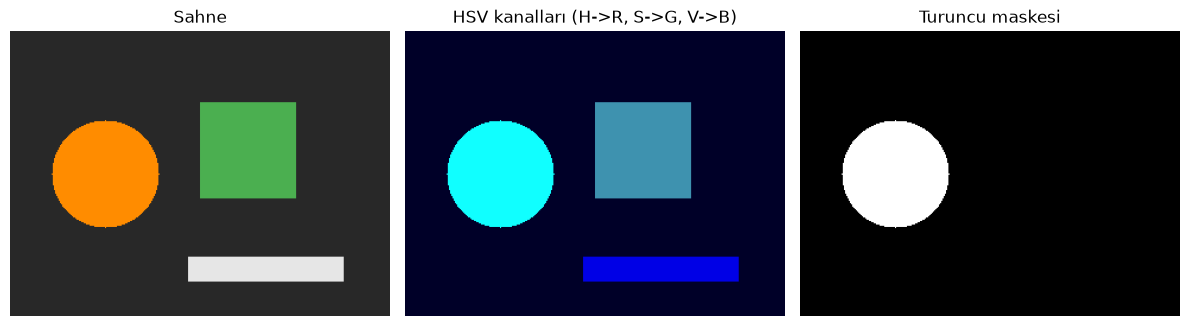

In [4]:
# Colab / yerel: eksikse
# !pip install -q opencv-python
# numpy sayı tablolarını, matplotlib çizimi yönetir: sahne üretimi ve panel gösterimi için şart.
import numpy as np
import matplotlib.pyplot as plt

# cv2 kurulu mu diye denenir; kurulu değilse hata yığını yerine okunur mesaj yazılır
# ve raise SystemExit(0) hücreyi sessizce bitirir (smoke testte hata sayılmaz).
try:
    import cv2
    print("OpenCV sürümü:", cv2.__version__)
except ImportError:
    print("cv2 kurulu değil: pip install opencv-python  (ders ortamında kurulu)")
    raise SystemExit(0)

# Sahne: koyu zemin üzerine turuncu daire, yeşil kare ve beyaz bir şerit
# Her pikseli 40 olan koyu 240x320 tuval; OpenCV kanal sırası BGR'dir (kırmızı en sona yazılır).
tuval = np.full((240, 320, 3), 40, dtype=np.uint8)            # BGR koyu zemin
# Merkez (80,120), yarıçap 45 dolu daire; BGR'de (0,140,255) turuncudur, -1 içi dolu demektir.
cv2.circle(tuval, (80, 120), 45, (0, 140, 255), -1)           # turuncu daire
# BGR'de (80,175,75) yeşil kare: maskenin onu dışarıda bırakacağını göreceğiz.
cv2.rectangle(tuval, (160, 60), (240, 140), (80, 175, 75), -1)      # yeşil kare
# Üç kanalı da yüksek olan beyaz şerit: kontrol grubu gibi durur.
cv2.rectangle(tuval, (150, 190), (280, 210), (230, 230, 230), -1)   # beyaz şerit

# BGR -> HSV
# BGR'den HSV'ye dönüşüm: renk cinsi tek kanala (H) toplanır.
hsv = cv2.cvtColor(tuval, cv2.COLOR_BGR2HSV)
# Aynı pikselin BGR ve HSV değerlerini yan yana basar: dönüşümün etkisi tek pikselde görünür.
print("dairenin merkezi  BGR:", tuval[120, 80], "->  HSV:", hsv[120, 80])

# Turuncu pikselleri yakala: H aralığı + yeterli doygunluk ve parlaklık
# Maske aralığı: H 5-25 bandı (turuncunun H'si yaklaşık 16), S ve V en az 120;
# doygunluk/parlaklık alt sınırı koyu zemini (V=40) eler.
alt_sinir = np.array([5, 120, 120])
# Aralığın üst sınırı: tam doygun, parlak pikselleri içerir.
ust_sinir = np.array([25, 255, 255])
# Aralık içinde kalan pikselleri 255, dışındakileri 0 yapan harita üretir:
# renk tabanlı seçim tek satırda biter, piksel piksel koşul yazmaya gerek kalmaz.
maske = cv2.inRange(hsv, alt_sinir, ust_sinir)
# (maske > 0).sum() ile yakalanan piksel sayısını saydırır: maskenin boş olmadığını kanıtlar.
print("maskede yakalanan piksel sayısı:", int((maske > 0).sum()))

# Üç panel yan yana: sahne, HSV, maske.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
# matplotlib RGB beklediği için kanalları çevirip basar; çevrilmezse kırmızıyla mavi yer değiştirir.
axes[0].imshow(cv2.cvtColor(tuval, cv2.COLOR_BGR2RGB))
axes[0].set_title("Sahne")
# HSV kanallarını gösterim amaçlı basar: H->R, S->G, V->B kanalına eşlenir.
axes[1].imshow(hsv)
axes[1].set_title("HSV kanalları (H->R, S->G, V->B)")
# Maskenin siyah-beyaz haritası: turuncu bölge beyaz görünür.
axes[2].imshow(maske, cmap="gray")
axes[2].set_title("Turuncu maskesi")
# Eksen cetvelini kapatır: görüntü panellerinde cetvel anlamsızdır.
for ax in axes:
    ax.axis("off")
# Panelleri yerleştirip ekrana basar.
plt.tight_layout(); plt.show()

## 3 · Konvolüsyon: Kernel'in Kayan Penceresi

**Konvolüsyon** (evrişim), görüntü işlemenin temel aritmetiğidir: küçük bir ağırlık tablosu — **kernel** — görüntünün üzerinde pencere pencere gezdirilir. Her konumda penceredeki 9 piksel ile kernel'in 9 ağırlığı çarpılır ve toplanır; çıkan tek sayı o noktadaki **tepkidir**: desen varsa yüksek, yoksa düşük.

$${\rm çıkış}(r, c) \;=\; \sum_{i=0}^{2}\sum_{j=0}^{2} K[i, j]\cdot {\rm girdi}[r+i,\; c+j]$$

Boyut hesabı basittir: $H \times W$ girdiye $k \times k$ kernel uygulanırsa çıktı $(H-k+1) \times (W-k+1)$ olur — 5×5'e 3×3 kernel → 3×3 çıktı.

> Derin öğrenmede fark şu: kernel değerleri elle seçilmez, **eğitim sırasında öğrenilir**. Sonraki oturumda bu pencereyi katman katman dizip ilk CNN'imizi kuracağız.

### Arka plandaki matematik

**Kernel** (ağırlık tablosu), görüntü üzerinde pencere pencere gezen küçük bir $k \times k$ sayı tablosudur; her konumda penceredeki 9 sayı ile kernel'deki 9 sayı çarpılıp toplanır ve çıktı matrisinin tek bir hücresi yazılır. Pencere kenara dayanınca sığmaz, bu yüzden çıktı küçülür:

$$(H - k + 1) \times (W - k + 1)$$

Elle örnek: $5 \times 5$ girdiye $k = 3$ → $(5 - 3 + 1) \times (5 - 3 + 1) = 3 \times 3$; her çıktı hücresi tam $9$ çarpım $+\,1$ toplama demektir.

> Bu blok konvolüsyon kayması için gerekli: klip pencerenin nasıl kaydığını gösteriyor; boyut formülü ve 9-çarpım hesabı baştan bilinirse animasyonda izlenenin ne olduğunu her adımda doğrulayabiliriz.


In [5]:
# Video gömme aracı (bölüm 1'dekiyle aynı).
from IPython.display import Video

# 3.1 — 3x3 kernel görüntü üzerinde nasıl kayar?
# İkinci ders klipini notebook içine gömer: 3x3 kernel'in pencere pencere kayışını animasyonla gösterir;
# boyut formülü (H-k+1) ile izlerken doğrulamak için.
Video("assets/02-konvolusyon-kaymasi.mp4", width=1000, embed=True)

### 3×3 kernel'i elle uygulayalım

Aşağıdaki 5×5 gri görüntüde sütun 2'de dikey bir kenar var: parlaklık 0'dan 8'e atlıyor. Sobel-x'e benzeyen bir kernel, soldan sağa parlaklık **farkını** ölçer; geçişin olduğu yerde tepki büyüktür. Döngüyle kuracağımız hesap, bir sonraki oturumda `nn.Conv2d` katmanının yapacağı işin ta kendisidir.

### Arka plandaki matematik

Her çıktı hücresi yine 9 çarpım + 1 toplamadır; bu hücre $(0, 0)$ penceresindeki dokuz çarpımı tek tek yazdırarak bunu elle doğrulanabilir kılar. Çıktı boyutu formülden gelir: $(5 - 3 + 1) \times (5 - 3 + 1) = 3 \times 3$.

> Bu blok için gerekli: konvolüsyonu elle adım adım görmek, "kernel ağırlıkları derin öğrenmede öğrenilir" fikrine somut zemin hazırlar — burada biz seçiyoruz, CNN'de ağ öğrenecek.


çıktı shape: (3, 3) -> (5-3+1) x (5-3+1)
[[32 32  0]
 [32 32  0]
 [32 32  0]]

(0,0) penceresindeki 9 çarpım:
  -1*0 =    0     0*0 =    0     1*8 =    8
  -2*0 =    0     0*0 =    0     2*8 =   16
  -1*0 =    0     0*0 =    0     1*8 =    8
toplam tepki = 32.0


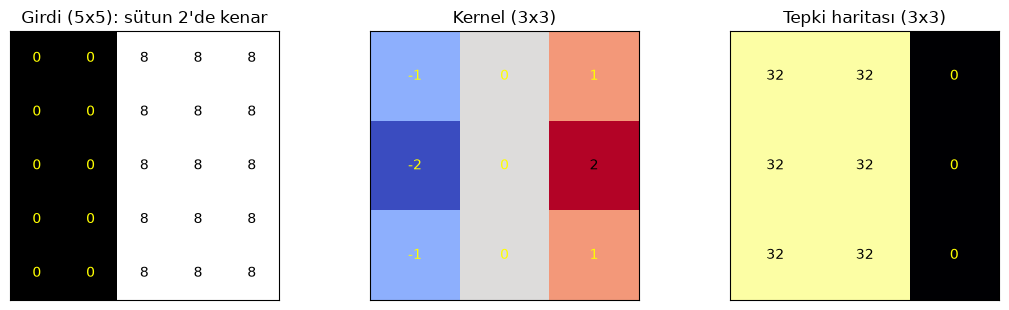

In [6]:
# numpy (dizi, dilimleme, matris aritmetiği) ile matplotlib (çizim) temel araçları; ikisi de şart.
import numpy as np
import matplotlib.pyplot as plt

# 5x5 gri görüntü: sütun 2'de dikey bir kenar (parlaklik 0 -> 8 atliyor)
# Aynı satırı 5 kez yığarak 5x5 gri görüntü üretir: sütun 2'deki 0 -> 8 sıçraması dikey kenardır.
giris = np.array([[0, 0, 8, 8, 8]] * 5, dtype=np.float32)

# Sobel-x'e benzeyen 3x3 kernel — derin ogrenmede bu degerler ogrenilir
# Soldan sağa parlaklık FARKINI ölçer: sağdaki parlak, soldaki koyuysa tepki büyüktür.
kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)

# Girdi boyutları ile kernel boyutu değişkenlere alınır;
# boyut formülü (H-k+1) x (W-k+1) bunlara dayanır.
H, W = giris.shape
k = kernel.shape[0]
# Çıktıyı boyut formülüyle tahsis eder: kernel kenardan taşamadığı için çıktı küçülür.
cikti = np.zeros((H - k + 1, W - k + 1), dtype=np.float32)

# Çıktının her hücresi için döner: pencere konumlarını sırayla üretir.
for r in range(cikti.shape[0]):
    for c in range(cikti.shape[1]):
        # numpy dilimlemesiyle 3x3 kayan pencereyi keser: "kayan pencere"nin ta kendisi.
        pencere = giris[r:r + k, c:c + k]        # kayan pencere
        # 9 çarpım + 1 toplama: eleman eleman çarpıp toplar; konvolüsyonun kalbi, tamamı 2 satır.
        cikti[r, c] = (pencere * kernel).sum()   # 9 çarpım + 1 toplama

# Çıktının 3x3 olduğunu boyut formülüyle doğrular.
print("çıktı shape:", cikti.shape, "-> (5-3+1) x (5-3+1)")
# Tepki haritasını sayı olarak basar: kenar sütununda 32'lik sıçrama görünür.
print(cikti.astype(int))

# (0,0) penceresindeki dokuz çarpımı tek tek yazdıralım
# Sol üst pencereyi ayrıca keser: elle doğrulama hedefi.
pencere = giris[0:3, 0:3]
print()
print("(0,0) penceresindeki 9 çarpım:")
# Elle birikmiş toplam: konvolüsyonun ürettiği değerle aynı çıkmalı.
toplam = 0.0
# Her satırın 3 çarpımını k*g = sonuç biçiminde tek satıra yazar:
# dokuz işlemin tamamı ekranda görünür.
for r in range(3):
    print("  ".join(f"{kernel[r, c]:>4.0f}*{pencere[r, c]:.0f} = {kernel[r, c] * pencere[r, c] + 0.0:>4.0f}"
                    for c in range(3)))
    # Aynı toplamı satır satır biriktirir: (0,0) hücresindeki tepkiyle eşleşmeli.
    toplam += (kernel[r] * pencere[r]).sum()
# Elle birikmiş toplamı basar: cikti[0,0] = 32 ile eşleşir.
print("toplam tepki =", toplam)

# Girdi, kernel ve tepki haritası yan yana üç panelde.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
# Girdi sabit gri ölçekte (0-8): kenarın yeri görünür.
axes[0].imshow(giris, cmap="gray", vmin=0, vmax=8)
axes[0].set_title("Girdi (5x5): sütun 2'de kenar")
# Kernel mavi (negatif) / kırmızı (pozitif) renklerle: işaret yapısı gözle okunur.
axes[1].imshow(kernel, cmap="coolwarm", vmin=-2, vmax=2)
axes[1].set_title("Kernel (3x3)")
# Tepki haritası sıcak renklerde: kenar nerede, tepki orada.
axes[2].imshow(cikti, cmap="inferno")
axes[2].set_title("Tepki haritası (3x3)")
# Her panelin karelerine değer yazar: sayı ile görsel birleşir.
for ax, d in zip(axes, [giris, kernel, cikti]):
    for r in range(d.shape[0]):
        for c in range(d.shape[1]):
            # Açık karelerde siyah yazı, koyuda sarı: okunabilirlik için.
            renk = "black" if d[r, c] > d.max() * 0.6 else "yellow"
            # (c, r) karesine o pikselin değerini yazar.
            ax.text(c, r, f"{d[r, c]:.0f}", ha="center", va="center",
                    fontsize=10, color=renk)
    # Eksen işaretlerini gizler: küçük matrislerde cetvel anlamsızdır.
    ax.set_xticks([]); ax.set_yticks([])
# Panelleri sıkıştırıp ekrana basar.
plt.tight_layout(); plt.show()

## 4 · OpenCV ile Ön İşleme: Bulanıklaştırma ve Kenarlar

Kenar aramadan önce gerçek görüntülerde üç klasik adım:

1. **Gri tonlama** — üç kanal tek parlaklık haritasına iner; kenar hesabı için yeterli.
2. **GaussianBlur** — her pikseli komşularının ortalamasıyla yumuşatır; **gürültüyü** (tek piksellik rastgele sıçramaları) bastırır. Yumuşatılmamış gürültü kenar algılayıcısını aldatır.
3. **Sobel** — yatay ($G_x$) ve dikey ($G_y$) yönde parlaklık değişimini ölçen iki konvolüsyon kernelidir. İkisinin büyüklüğü $\sqrt{G_x^2 + G_y^2}$ bize **kenar haritasını** verir.

Kenarın tanımı da budur: **parlaklığın hızlı değiştiği yer**.

### Arka plandaki matematik

Gri tonlama, üç kanalı tek parlaklığa indiren ağırlıklı ortalamadır; ağırlıklar gözün yeşile en duyarlı, maviye en duyarsız olmasından gelir:

$$\text{gri} = 0{,}299\,R + 0{,}587\,G + 0{,}114\,B$$

Elle örnek — yeşil karedeki bir piksel, $R = 75, G = 175, B = 80$: $0{,}299 \cdot 75 + 0{,}587 \cdot 175 + 0{,}114 \cdot 80 = 22{,}4 + 102{,}7 + 9{,}1 \approx 134$. Yani üç sayı tek 134'e iner.

Kenar, parlaklıktaki ani değişimdir; **Sobel** filtresi her yöndeki değişimi (gradyan, $\nabla$) ölçer ve büyüklüğü birleştirir:

$$\|\nabla I\| = \sqrt{G_x^2 + G_y^2}$$

Elle örnek: bir pikselde $G_x = 3, G_y = 4 \Rightarrow \sqrt{9 + 16} = 5$; değişim iki yönde birden olsa bile tek sayıya iner.

> Bu blok bulanıklaştırma + kenar zinciri için gerekli: bulanıklaştırma piksel düzeyindeki gürültüyü bastırır ki Sobel yalnız gerçek kenarlara tepki versin; ağırlıkların ve büyüklük formülün sayısal karşılığını görmek çıktı haritasını okumayı kolaylaştırır.


gri shape: (240, 320) | değer aralığı: 40 - 230
Sobel büyüklüğü: maks = 328.0


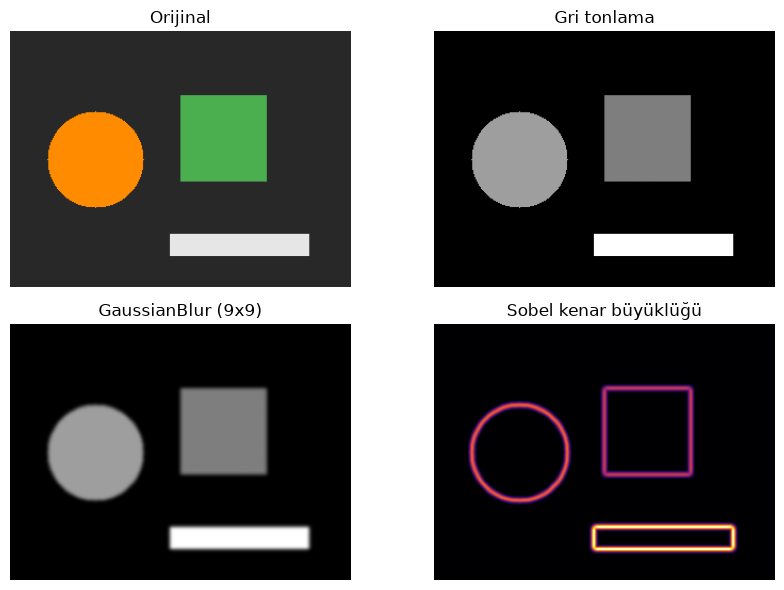

In [7]:
# Colab / yerel: eksikse
# !pip install -q opencv-python
# numpy sayı tablolarını, matplotlib çizimi yönetir: zincirin dört aşamasını göstermek için şart.
import numpy as np
import matplotlib.pyplot as plt

# cv2 kurulu değilse okunur mesaj yazıp raise SystemExit(0) ile hücreyi sessizce bitirir;
# hücre 12'deki kalıbın aynısı; smoke testte hata sayılmaz.
try:
    import cv2
except ImportError:
    print("cv2 kurulu değil: pip install opencv-python  (ders ortamında kurulu)")
    raise SystemExit(0)

# Aynı sahneyi yeniden üretiyoruz (hücre tek başına da çalışabilsin diye)
tuval = np.full((240, 320, 3), 40, dtype=np.uint8)
cv2.circle(tuval, (80, 120), 45, (0, 140, 255), -1)
cv2.rectangle(tuval, (160, 60), (240, 140), (80, 175, 75), -1)
cv2.rectangle(tuval, (150, 190), (280, 210), (230, 230, 230), -1)
# Üç kanalı ağırlıklı ortalamayla tek parlaklığa indirger (gri = 0.299R + 0.587G + 0.114B):
# kenar hesabı tek kanal üzerinde yapılır, bellekten de kazanır.
gri = cv2.cvtColor(tuval, cv2.COLOR_BGR2GRAY)
# Kanal sayısının 3'ten 1'e düştüğünü kanıtlar: [240,320,3] -> [240,320].
print("gri shape:", gri.shape, "| değer aralığı:", int(gri.min()), "-", int(gri.max()))

# 1) bulanıklaştırma: gürültüyü bastır
# 9x9 Gauss filtresiyle yumuşatır: piksel düzeyindeki gürültü Sobel'de sahte kenar üretirdi;
# önce bastırılır ki tepki haritası temiz çıksın.
bulanik = cv2.GaussianBlur(gri, (9, 9), 0)

# 2) Sobel ile kenarlar
# x yönündeki parlaklık değişimini ölçer; "1, 0" = x türevi var, y türevi yok.
sobel_x = cv2.Sobel(bulanik, cv2.CV_64F, 1, 0, ksize=3)
# Aynı işin y yönü karşılığı; CV_64F negatif gradyanların kaybolmamasını sağlar.
sobel_y = cv2.Sobel(bulanik, cv2.CV_64F, 0, 1, ksize=3)
# Büyüklük formülünün kod hâli: iki yönlü tepkiyi tek haritada birleştirir.
kenar = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
# En güçlü kenar tepkisini yazdırır: çıktı aralığını önceden biliriz.
print("Sobel büyüklüğü: maks =", round(float(kenar.max()), 1))

# 2x2 panel: zincirin dört aşaması birden — orijinal, gri, bulanık, kenar.
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
# Orijinal sahne; matplotlib RGB beklediği için BGR->RGB çevrilir.
axes[0, 0].imshow(cv2.cvtColor(tuval, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Orijinal")
# Gri tonlama sonucu: şekiller artık parlaklıkla ayrışır.
axes[0, 1].imshow(gri, cmap="gray")
axes[0, 1].set_title("Gri tonlama")
# Yumuşatılmış hâli: kenarlar hafif silinir ama gürültü de gider.
axes[1, 0].imshow(bulanik, cmap="gray")
axes[1, 0].set_title("GaussianBlur (9x9)")
# Kenar büyüklüğü haritası: kenarlar sıcak renklerde parlar.
axes[1, 1].imshow(kenar, cmap="inferno")
axes[1, 1].set_title("Sobel kenar büyüklüğü")
# ravel 2x2 grid'i tek listede gezmeyi sağlar; eksenler kapatılır.
for ax in axes.ravel():
    ax.axis("off")
# Panelleri sıkıştırıp ekrana basar.
plt.tight_layout(); plt.show()

## 5 · numpy'den PyTorch'a: Modelin Beklediği Düzen

Bir CNN'e girmeden önce her görüntü şu diziden geçer — her adım tek satır:

| Adım | Kod | Ne yapar |
|---|---|---|
| 1. Tensöre al | `torch.from_numpy(dizi)` | numpy dizisini tensöre çevirir — **belleği paylaşır**, kopyalamaz |
| 2. Kanal sırası | `img[:, :, [2, 1, 0]]` | cv2'den gelen BGR'yi RGB'ye çevirir |
| 3. Ölçek | `.float() / 255.0` | 0–255 → 0–1 |
| 4. Düzen | `.permute(2, 0, 1)` | `[H, W, C]` → `[C, H, W]` (CHW) |
| 5. Batch | `.unsqueeze(0)` | başa `[B]` boyutunu ekler |

İki ayrıntı: `from_numpy` belleği paylaştığı için numpy dizisini değiştirmek tensörü de değiştirir; bağımsız kopya `.clone()` ile alınır. `permute` ise veriyi taşımaz, sadece boyutların **okunma sırasını** değiştirir; bu yüzden sonuç bellekte "düz" değildir ve bazı işlemlerden önce `.contiguous()` gerekir.

Modelin gördüğü son şekil: `[B, C, H, W]` — örneğin `[32, 3, 64, 96]`.

### Arka plandaki matematik

Bir CNN'e girmeden önce her görüntü üç matematiksel adımdan geçer; hepsi tek satır kod:

1. **Ölçekleme:** $x' = x/255$ — değerler $[0, 1]$'e iner.
2. **Eksen düzeni:** model $[B, C, H, W]$ (kanal önde, CHW) bekler; `permute(2, 0, 1)` eksenleri yeniden sıralar, $[H, W, C] \to [C, H, W]$ — **veri taşınmaz**, sadece eksen yorumu değişir.
3. **Standardizasyon:** her kanaldan ortalama çıkarılıp sapmaya bölünür:
$$x'' = \frac{x' - \mu}{\sigma}$$

Elle örnek: beyaz piksel $x' = 1{,}0$, $\mu = 0{,}485$, $\sigma = 0{,}229 \Rightarrow x'' = (1 - 0{,}485)/0{,}229 \approx 2{,}25$. Yani modelin gördüğü sayılar $[0, 1]$ bile değildir; yaklaşık $[-2{,}1, +2{,}6]$ bandındadır.

> Bu blok numpy↔torch köprüsü için gerekli: eğitim öncesi düzenleme zincirini tek yerde toplar; ileride "boyut hatası" veya "değerler uçuk" yaşadığımızda hatanın hangi adımda olduğunu tek bakışta bulmamızı sağlar.


In [8]:
# numpy (dizi üretimi), torch (tensörler), F (conv2d gibi tensör fonksiyonları);
# numpy'dan sonraki durak: modelin beklediği düzeni burada kuruyoruz.
import numpy as np
import torch
import torch.nn.functional as F

# Hücreyi tek başına çalıştırmak için 64x96'lık görüntüyü yeniden üretiyoruz
H, W = 64, 96
yy, xx = np.mgrid[0:H, 0:W]
t = (yy + xx) / (H + W - 2)
img_bgr = np.zeros((H, W, 3), dtype=np.uint8)     # cv2 alışkanlığı: BGR sırası
img_bgr[..., 0] = 82 - 46 * t                     # B
img_bgr[..., 1] = 88 + 103 * t                    # G
img_bgr[..., 2] = 23 + 228 * t                    # R

# 1) numpy -> torch: bellek paylaşılır
# numpy dizisini tensöre çevirir ama kopya ALMAZ: belleği paylaşır;
# numpy dizisi değişirse tensör de değişir — bağımsız kopya .clone() ile alınır.
img_t = torch.from_numpy(img_bgr)
# Şekil (64, 96, 3) ve tip uint8: dönüşümde hiçbir şey değişmedi.
print("from_numpy     :", tuple(img_t.shape), img_t.dtype)

# 2) cv2'den geliyorsa kanallar BGR'dir -> RGB'ye çevir
# Kanal eksenini ters sırayla dilimler: BGR -> RGB; cv2'den gelen görüntü BGR'dir, model RGB bekler.
img_rgb = img_t[:, :, [2, 1, 0]]
# Şekil aynı kalır, sadece kanal anlamı değişir.
print("BGR -> RGB     :", tuple(img_rgb.shape))

# 3) ölçek: 0-255 -> 0-1
# float() tipi float32'ye çevirir; 255'e bölme x' = x/255 ölçeklemesini uygular.
img_f = img_rgb.float() / 255.0
# Değer bandını basar: 0.09 - 1.00.
print("float / 255    : değerler", f"{img_f.min():.2f} - {img_f.max():.2f}")

# 4) HWC -> CHW
# Eksenleri [H,W,C] -> [C,H,W] sıralar: VERİ TAŞINMAZ, sadece okunma sırası değişir;
# conv2d kanalı ikinci eksende bekler, son eksende değil.
img_chw = img_f.permute(2, 0, 1)
# Yeni şekil ve bellek düzeni: permute sonrası bitişik (contiguous) değildir.
print("permute(2,0,1) :", tuple(img_chw.shape), "| contiguous:", img_chw.is_contiguous())

# 5) batch boyutu ekle
# Başa 1'lik eksen ekler: [3,64,96] -> [1,3,64,96]; model girdiyi her zaman yığın alır.
img_batch = img_chw.unsqueeze(0)
# Modelin gördüğü son şekli [B, C, H, W] olarak basar.
print("unsqueeze(0)   :", tuple(img_batch.shape), "-> [B, C, H, W]")

# 6) mean/std normalizasyonu (görüntü sınıflandırma modellerinin alışkanlığı)
# ImageNet kanal ortalamaları; view(3,1,1) kanal-başına yayınlanabilir şekil verir:
# tek satırda tüm görüntüye uygulanabilir.
ort = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
# Kanal standart sapmaları, aynı [3,1,1] şekil.
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# x'' = (x' - mu) / sigma standardizasyonu: modelin eğitim verisiyle aynı ölçeğe oturur.
img_std = (img_batch - ort) / std
# Değer bandını basar: yaklaşık -1.7 - 2.25; [0,1]'den uzak, standardize.
print("mean/std sonra :", f"{img_std.min():.2f} - {img_std.max():.2f}")

# 7) küçük crop: tensor dilimlemek = görüntü kırpmak
# Tensor dilimlemesiyle 32x48 bölgeyi keser: görüntü kırpma = dilimleme; veri kopyalanmaz.
kirpik = img_f[16:48, 24:72]
# Kırpılan bölgenin şeklini basar: (32, 48, 3).
print("crop           :", tuple(kirpik.shape), "-> img_f[16:48, 24:72]")

# 8) torch ile konvolüsyon: bölüm 3'teki elle hesabın birebir karşılığı
# Bölüm 3'teki elle hesabın girdisi ve Sobel-x kernel'i yeniden kurulur.
giris = np.array([[0, 0, 8, 8, 8]] * 5, dtype=np.float32)
kernel_np = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
# Tensöre çevirip [B,C,H,W] = [1,1,5,5] biçimine sokar: conv2d bu düzeni bekler.
giris_t = torch.from_numpy(giris).view(1, 1, 5, 5)
# Kernel için aynı düzenleme: [1,1,3,3].
kernel_t = torch.from_numpy(kernel_np).view(1, 1, 3, 3)
# Konvolüsyonu tek çağrıyla uygular: elle döngünün birebir kütüphane karşılığı.
cikti_t = F.conv2d(giris_t, kernel_t)
# Elle hesapta beklenen sonucu kurar (alttaki satır kenar sütunlarına 32 yazar):
# karşılaştırma hedefi.
beklenen = torch.zeros(1, 1, 3, 3)
beklenen[..., 0:2] = 32.0
print()
# Başlık satırı.
print("F.conv2d çıktısı:")
# conv2d çıktısını sayı tablosu olarak basar.
print(cikti_t[0, 0].to(torch.int))
# Birebir eşitliği True ile kanıtlar: aynı matematik, farklı araç.
print("bölüm 3'teki elle hesapla birebir aynı mı?", torch.equal(cikti_t, beklenen))

from_numpy     : (64, 96, 3) torch.uint8
BGR -> RGB     : (64, 96, 3)
float / 255    : değerler 0.09 - 0.98
permute(2,0,1) : (3, 64, 96) | contiguous: False
unsqueeze(0)   : (1, 3, 64, 96) -> [B, C, H, W]
mean/std sonra : -1.72 - 2.18
crop           : (32, 48, 3) -> img_f[16:48, 24:72]

F.conv2d çıktısı:
tensor([[32, 32,  0],
        [32, 32,  0],
        [32, 32,  0]], dtype=torch.int32)
bölüm 3'teki elle hesapla birebir aynı mı? True


## Mini Quiz

1. `uint8` tipinde 0–255 aralığındaki bir görüntüyü modele vermeden önce neden 0–1 aralığına çekiyoruz?
2. `[240, 320, 3]` şeklindeki bir `numpy` dizisini PyTorch'un istediği `[1, 3, 240, 320]` biçimine getirmek için hangi işlemler gerekir?
3. 6×6 boyutunda bir girdiye 3×3 kernel uygularsak çıktının şekli ne olur?
4. OpenCV görüntüyü neden BGR sırasıyla verir? PyTorch'a vermeden önce ne yapmalıyız?
5. Renk tabanlı maske çıkarmak için RGB yerine HSV kullanmak neden daha sağlamdır?
6. `torch.from_numpy` ile üretilen tensör numpy dizisiyle neyi paylaşır? Bağımsız bir kopya nasıl alınır?

### Cevaplar

<details><summary>Açmak için tıkla</summary>

1. Ağlar float sayılarla ve benzer ölçeklerle çalışmayı sever; 0–255 gibi büyük değerler gradyanları kararsızlaştırır. Tüm girdileri benzer aralığa çekmek eğitimi hem kararlı hem hızlı yapar.
2. Önce `permute(2, 0, 1)` ile `[H, W, 3]` → `[3, 240, 320]` (CHW), sonra `unsqueeze(0)` ile başa batch boyutu.
3. $(6-3+1) \times (6-3+1) = 4 \times 4$.
4. Tarihsel bir alışkanlık: OpenCV BGR sırasını korur. Görselleştirme veya PyTorch öncesi `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` ile kanallar çevrilir.
5. HSV'de renk cinsi tek kanalda (H) toplanır; ışık değişimi çoğunlukla V'yi etkiler, H'yi korur. RGB'de ise gölge üç kanalı birden oynatır.
6. Belleği paylaşır: numpy dizisi değişirse tensör de değişir. Bağımsız kopya için `.clone()` çağrılır.

</details>

---

## Özet

- Görüntü = sayı tablosu: gri `[H, W]`, renkli `[H, W, 3]`; pikseller `uint8` ve 0–255.
- Model öncesi düzenleme: `float() / 255`, `permute(2, 0, 1)` (HWC → CHW), `unsqueeze(0)` (batch) — son şekil `[B, C, H, W]`.
- HSV rengi parlaklıktan ayırır; renk maskesi tek bir H aralığıyla çıkarılır.
- Konvolüsyon: kernel pencere pencere gezer, her konumda 9 çarpım + 1 toplama; çıktı $(H-k+1) \times (W-k+1)$.
- OpenCV araçları: `cvtColor` (gri/HSV), `GaussianBlur` (gürültü bastırma), `Sobel` (kenar).

**Sonraki oturum:** Bu kayan pencereyi katman katman diziyoruz — konvolüsyon ve pooling katmanlarıyla ilk CNN mimarimizi kurup CIFAR-10 üzerinde eğitiyoruz.

## Kaynakça

- OpenCV — Renk uzayları: <https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html>
- OpenCV — Görüntü gradyanları (Sobel): <https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html>
- OpenCV — Yumuşatma filtreleri: <https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html>
- PyTorch — `torch.from_numpy`: <https://pytorch.org/docs/stable/generated/torch.from_numpy.html>
- PyTorch — Transforms (görüntü ön işleme): <https://pytorch.org/tutorials/beginner/basics/transforms_tutorial.html>
- Goodfellow, Bengio, Courville — *Deep Learning*, Böl. 9 (ücretsiz): <https://www.deeplearningbook.org>

## Kodlama Soruları

Bu oturumun kodları üzerinden 5 küçük kodlama görevi. Her görevde beklenen çıktı tanımlı; çözüm taslağı sorunun altındaki kutuda.

1. `normalize_et` adında bir fonksiyon yaz: `uint8` tipinde $[H, W, 3]$ şeklinde bir numpy dizisini alıp `float32` tipinde 0–1 aralığına çeksin. Bölüm 1'deki $8 \times 8$ görüntüyle test et; beklenen: `dtype` `float32`, minimum yaklaşık $0{,}09$, maksimum yaklaşık $0{,}98$.

<details><summary>Çözüm fikri</summary>

```python
def normalize_et(img):
    return img.astype(np.float32) / 255.0

img_norm = normalize_et(img_255)
print(img_norm.dtype, img_norm.min(), img_norm.max())
# float32 0.090 0.984
```

Önce `astype` ile tip değişimi şart: `uint8` üzerinde doğrudan işlem yapılsaydı sonuç yine `uint8` kalır ve 255'ten büyük değerler taşarak bozulurdu. (Görüntümüzün en parlak pikseli $R = 251$'dir; $251/255 \approx 0{,}984$.)

</details>

2. Bölüm 3'teki elle konvolüsyon döngüsünü **kendi kernel'inle** çalıştır: tüm ağırlıkları $1/9$ olan bir $3 \times 3$ blur kernel'i tanımla, $6 \times 6$'lık rastgele bir girdiye uygula. Çıktının şekli $(6 - 3 + 1) \times (6 - 3 + 1) = 4 \times 4$ olmalı ve her hücre çevresindeki 9 pikselin ortalaması olmalı.

<details><summary>Çözüm fikri</summary>

```python
kernel = np.full((3, 3), 1 / 9, dtype=np.float32)
giris = np.random.rand(6, 6).astype(np.float32)
cikti = np.zeros((4, 4), dtype=np.float32)
for r in range(4):
    for c in range(4):
        cikti[r, c] = (giris[r:r + 3, c:c + 3] * kernel).sum()
print(cikti.shape)   # (4, 4)
```

Aynı kernel'i `torch.from_numpy(...).view(1, 1, 3, 3)` ile `F.conv2d`'ye verip `torch.allclose` ile eşitliği de doğrulayabilirsin — blur, ortalama alan bir kernel'dir.

</details>

3. Bölüm 5'teki $64 \times 96$'lık görüntüden merkezdeki $32 \times 48$'lik bölgeyi tensor dilimlemesiyle kes. Beklenen çıktı şekli `[32, 48, 3]` olmalı.

<details><summary>Çözüm fikri</summary>

```python
kirpik = img_f[16:48, 24:72]
print(tuple(kirpik.shape))   # (32, 48, 3)
```

Görüntü kırpma = tensor dilimleme: satırları 16–47, sütunları 24–71 alırız; veri taşınmaz, sadece seçilir.

</details>

4. Bir arkadaşın kodu hata veriyor: `img_t = torch.from_numpy(img_bgr)` yazdıktan sonra doğrudan `F.conv2d(img_t.unsqueeze(0), kernel_t)` çağırıyor ve `RuntimeError` alıyor — tensör `uint8`, kernel `float32`. Hatayı bul, eksik adımları (ölçekleme ve eksen düzeni dahil) tamamla; beklenen son şekil $[1, C, H, W]$.

<details><summary>Çözüm fikri</summary>

```python
img_f = img_t[:, :, [2, 1, 0]].float() / 255.0
cikti = F.conv2d(img_f.unsqueeze(0).permute(0, 3, 1, 2), kernel_t)
```

İki eksik vardı: `uint8` tensör önce `float32`'ye çevrilmeli (ve /255 ile normalize edilmeli); ayrıca `unsqueeze` sonrası hâlâ HWC düzenindedir, `permute` ile CHW'ye taşınmalı. Son şekil $[1, 3, H, W]$ olur.

</details>

5. Bölüm 2'deki sahnede bu kez **yeşil kareyi** HSV maskeyle yakala: `alt_sinir` ve `ust_sinir` değerlerini belirle, `cv2.inRange` ile maske üret, yakalanan piksel sayısını yazdır. Yeşil karenin $H$'si bu sahnede yaklaşık 61'dir (OpenCV ölçeğinde); $S$ ve $V$ alt sınırları koyu zemini eler. Beklenen: piksel sayısı $81 \times 81 = 6561$ — kare kenarları dahil.

<details><summary>Çözüm fikri</summary>

```python
alt_sinir = np.array([40, 120, 120])
ust_sinir = np.array([80, 255, 255])
maske = cv2.inRange(hsv, alt_sinir, ust_sinir)
print("yeşil piksel sayısı:", int((maske > 0).sum()))
# yeşil piksel sayısı: 6561
```

$H$ bandı $56 - 66$ gibi dar da tutulabilir; geniş tutmak kenar köşelerindeki küçük ton kaymalarını da güvenceye alır. $S, V \geq 120$ alt sınırı koyu zeminin ($V = 40$) maskeye girmesini engeller.

</details>
